# Notebook 13: Cross-Validation Fold Comparison

This notebook compares 5-fold, 7-fold, and 10-fold cross-validation as candidate validation settings for the project's later workflow.

To keep the notebook self-contained while staying aligned with the main codebase, the key helper logic is written directly inside the notebook in a form that mirrors the corresponding `src` implementations.


## Why Revisit Fold Count?

Once the project moved beyond the early holdout-validation stage, the next methodological question was not only which model to use, but also how to evaluate it reliably. Fold count matters because it changes three practical quantities at the same time:
- the mean CV AUC, which summarizes central validation performance
- the standard deviation across folds, which summarizes stability
- the runtime cost, which affects how practical the validation setting is during iterative development

For the final choice, the goal is not to optimize only one metric. Instead, the notebook looks for a practical balance between validation performance, stability, and computational cost.


In [1]:
from dataclasses import dataclass
from pathlib import Path
import json
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
LOG_DIR = PROJECT_ROOT / 'logs'
LOG_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'diagnosed_diabetes'
RANDOM_SEED = 42
MAX_TRAIN_ROWS = None
FOLD_OPTIONS = [5, 7, 10]
PREFERRED_FOLD = 7

ARTIFACT_CSV = LOG_DIR / 'fold_count_comparison.csv'
ARTIFACT_JSON = LOG_DIR / 'fold_count_comparison.json'
ARTIFACT_MD = LOG_DIR / 'fold_count_comparison.md'
ARTIFACT_PNG = LOG_DIR / 'fold_count_comparison.png'

CATEGORICAL_COLS = [
    'gender', 'ethnicity', 'education_level',
    'income_level', 'smoking_status', 'employment_status'
]

if hasattr(sns, 'set_theme'):
    sns.set_theme(style='whitegrid', context='talk')
else:
    sns.set_style('whitegrid')
    sns.set_context('talk')
plt.rcParams['figure.figsize'] = (10, 6)


@dataclass
class ExperimentConfig:
    use_family_history_features: bool = True
    use_cholesterol_features: bool = True


CONFIG = ExperimentConfig()


def add_engineered_features(df: pd.DataFrame, config: ExperimentConfig = None) -> pd.DataFrame:
    if config is None:
        config = ExperimentConfig()

    df = df.copy()

    if config.use_family_history_features:
        df['age_family_history'] = df['age'] * df['family_history_diabetes']
        df['age_bmi'] = df['age'] * df['bmi']
        df['cardio_risk_score'] = (
            df['family_history_diabetes'] * 3
            + df['hypertension_history'] * 2
            + df['cardiovascular_history'] * 2
        )

    if config.use_cholesterol_features:
        df['cholesterol_ratio'] = df['cholesterol_total'] / (df['hdl_cholesterol'] + 1)
        df['non_hdl_cholesterol'] = df['cholesterol_total'] - df['hdl_cholesterol']

    return df


def build_xgb_model(seed: int = RANDOM_SEED) -> XGBClassifier:
    return XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        tree_method='hist',
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=1,
        reg_alpha=0.1,
        reg_lambda=1,
        random_state=seed,
        n_jobs=-1,
        early_stopping_rounds=100,
        verbosity=0,
    )


def load_data(sample_cap=None) -> pd.DataFrame:
    train_df = pd.read_csv(DATA_DIR / 'train.csv')
    if sample_cap is not None and len(train_df) > sample_cap:
        train_df = train_df.iloc[:sample_cap].reset_index(drop=True)
    return train_df


def prepare_features(train_df: pd.DataFrame, config: ExperimentConfig = None):
    if config is None:
        config = ExperimentConfig()

    X = train_df.drop(columns=['id', TARGET]).copy()
    y = train_df[TARGET].astype(int).copy()

    X = add_engineered_features(X, config)

    categorical_cols = [col for col in CATEGORICAL_COLS if col in X.columns]
    for col in categorical_cols:
        X[col] = X[col].fillna('Unknown').astype(str)

    return X, y, categorical_cols


def _encode_categorical_fold(
    X_train_raw: pd.DataFrame,
    X_valid_raw: pd.DataFrame,
    categorical_cols,
):
    X_train_encoded = X_train_raw.copy()
    X_valid_encoded = X_valid_raw.copy()

    for col in categorical_cols:
        if col not in X_train_encoded.columns:
            continue

        le = LabelEncoder()
        X_train_encoded[col] = le.fit_transform(X_train_encoded[col].astype(str))

        try:
            X_valid_encoded[col] = le.transform(X_valid_encoded[col].astype(str))
        except ValueError:
            X_valid_encoded[col] = -1

    missing_valid = set(X_train_encoded.columns) - set(X_valid_encoded.columns)
    for col in missing_valid:
        X_valid_encoded[col] = 0
    X_valid_encoded = X_valid_encoded[X_train_encoded.columns]

    return X_train_encoded, X_valid_encoded


def run_standard_xgb_cv_benchmark(X, y, categorical_cols, random_state=RANDOM_SEED, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_pred = np.zeros(len(X))
    fold_scores = []
    best_iterations = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        X_train_raw = X.iloc[train_idx]
        X_valid_raw = X.iloc[valid_idx]
        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        X_train_encoded, X_valid_encoded = _encode_categorical_fold(
            X_train_raw, X_valid_raw, categorical_cols
        )

        model = build_xgb_model(seed=random_state + fold)
        model.fit(
            X_train_encoded,
            y_train,
            eval_set=[(X_valid_encoded, y_valid)],
            verbose=False,
        )

        valid_pred = model.predict_proba(X_valid_encoded)[:, 1]
        fold_auc = roc_auc_score(y_valid, valid_pred)
        oof_pred[valid_idx] = valid_pred
        fold_scores.append(float(fold_auc))
        best_iterations.append(getattr(model, 'best_iteration', None))

    return {
        'fold_aucs': fold_scores,
        'mean_auc': float(np.mean(fold_scores)),
        'std_auc': float(np.std(fold_scores)),
        'oof_auc': float(roc_auc_score(y, oof_pred)),
        'best_iterations': best_iterations,
        'oof_pred': oof_pred,
    }


def dataframe_to_markdown(df: pd.DataFrame) -> str:
    if df.empty:
        return '| empty |\n| --- |'
    columns = [str(col) for col in df.columns]
    header = '| ' + ' | '.join(columns) + ' |'
    separator = '| ' + ' | '.join(['---'] * len(columns)) + ' |'
    rows = []
    for _, row in df.iterrows():
        cells = []
        for value in row.tolist():
            if isinstance(value, float):
                cells.append(f'{value:.6f}')
            else:
                cells.append(str(value))
        rows.append('| ' + ' | '.join(cells) + ' |')
    return '\n'.join([header, separator, *rows])


print(f'Project root: {PROJECT_ROOT}')
print(f'Data directory: {DATA_DIR}')
print(f'Artifacts directory: {LOG_DIR}')
print(f'Max train rows: {MAX_TRAIN_ROWS}')
print(f'Fold options: {FOLD_OPTIONS}')


Project root: c:\Users\LENOVO\Desktop\machinelearning_project
Data directory: c:\Users\LENOVO\Desktop\machinelearning_project\data
Artifacts directory: c:\Users\LENOVO\Desktop\machinelearning_project\logs
Max train rows: None
Fold options: [5, 7, 10]


## Data Loading and Feature Preparation

This section loads the raw training data directly from the repository and prepares features using notebook-local code that mirrors the main `src` pipeline. The feature engineering logic is aligned with the project implementation, but it is defined inline here so the notebook remains standalone.

The default setting uses the full training set. In this repository, that means all **700,000** training rows are included unless you manually set `MAX_TRAIN_ROWS` to a smaller value for a faster exploratory run.


In [2]:
train_df = load_data(sample_cap=MAX_TRAIN_ROWS)
X, y, categorical_cols = prepare_features(train_df, config=CONFIG)

if MAX_TRAIN_ROWS is None:
    print(f'Using the full training set: {len(train_df):,} rows')
else:
    print(f'Using a capped training set: {len(train_df):,} rows')

overview_df = pd.DataFrame(
    {
        'rows': [len(train_df)],
        'feature_count': [X.shape[1]],
        'categorical_features': [len(categorical_cols)],
        'target_positive_rate': [float(y.mean())],
    }
)

display(overview_df)
X.head()


Using the full training set: 700,000 rows


,rows,feature_count,categorical_features,target_positive_rate
0,700000,29,6,0.623296


,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,age_family_history,age_bmi,cardio_risk_score,cholesterol_ratio,non_hdl_cholesterol
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,...,Current,Employed,0,0,0,0,1035.4,0,3.372881,141
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,...,Never,Employed,0,0,0,0,1190.0,0,3.901961,149
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,...,Never,Retired,0,0,0,0,771.2,0,3.133333,129
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,...,Current,Employed,0,1,0,0,1436.4,2,3.309091,128
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,...,Never,Retired,0,1,0,0,1555.2,2,4.120000,157


## Method

For each candidate fold count, the notebook runs the same ordinary stratified XGBoost cross-validation benchmark and records:
- fold-level AUCs
- mean CV AUC
- standard deviation of CV AUC
- OOF AUC
- elapsed runtime

The notebook is intended to be numerically consistent with the main `src` training path when the fold count is set to 7 and the full training set is used. The final decision is based on the overall trade-off: stronger validation performance is valuable, but it should be weighed against fold-to-fold stability and runtime.


In [3]:
rows = []
benchmark_details = {}

for n_splits in FOLD_OPTIONS:
    start = time.perf_counter()
    benchmark = run_standard_xgb_cv_benchmark(
        X=X,
        y=y,
        categorical_cols=categorical_cols,
        random_state=RANDOM_SEED,
        n_splits=n_splits,
    )
    elapsed = time.perf_counter() - start

    row = {
        'fold_count': n_splits,
        'fold_aucs': benchmark['fold_aucs'],
        'mean_auc': benchmark['mean_auc'],
        'std_auc': benchmark['std_auc'],
        'oof_auc': benchmark['oof_auc'],
        'runtime_seconds': float(elapsed),
        'preferred_fold': n_splits == PREFERRED_FOLD,
    }
    rows.append(row)
    benchmark_details[n_splits] = benchmark

results_df = pd.DataFrame(rows).sort_values('fold_count').reset_index(drop=True)
results_df

,fold_count,fold_aucs,mean_auc,std_auc,oof_auc,runtime_seconds,preferred_fold
0,5,"[0.7259607017518144, 0.7242820168772737, 0.725...",0.725611,0.000835,0.725604,409.458535,False
1,7,"[0.725554247452194, 0.7257677950124684, 0.7258...",0.725852,0.001294,0.725845,513.805212,True
2,10,"[0.7256989210291179, 0.7271457402833745, 0.724...",0.725908,0.001466,0.725905,676.504081,False


## Results Table

The comparison table below is the main decision surface for this notebook. In practice, the most useful columns are:
- `mean_auc` for central validation performance
- `std_auc` for stability
- `runtime_seconds` for development cost

A fold count that is only marginally stronger in AUC but substantially heavier in runtime may not be the best operating point for an iterative course-project workflow.

In [ ]:
display_df = results_df.copy()
display_df['fold_aucs'] = display_df['fold_aucs'].apply(
    lambda scores: ', '.join(f'{score:.4f}' for score in scores)
)
display_df['mean_auc'] = display_df['mean_auc'].map(lambda x: f'{x:.6f}')
display_df['std_auc'] = display_df['std_auc'].map(lambda x: f'{x:.6f}')
display_df['oof_auc'] = display_df['oof_auc'].map(lambda x: f'{x:.6f}')
display_df['runtime_seconds'] = display_df['runtime_seconds'].map(lambda x: f'{x:.2f}')

display(display_df)

## Visualization

The visualization is organized around the trade-off that drives the final choice.

The two panels play different roles:
- the left panel shows the performance-stability trade-off directly
- the right panel adds runtime as an operational constraint

Under this framing, 7-fold is not presented as the absolute best on every single metric. It is presented as the most practical balance across the main criteria used in this notebook.


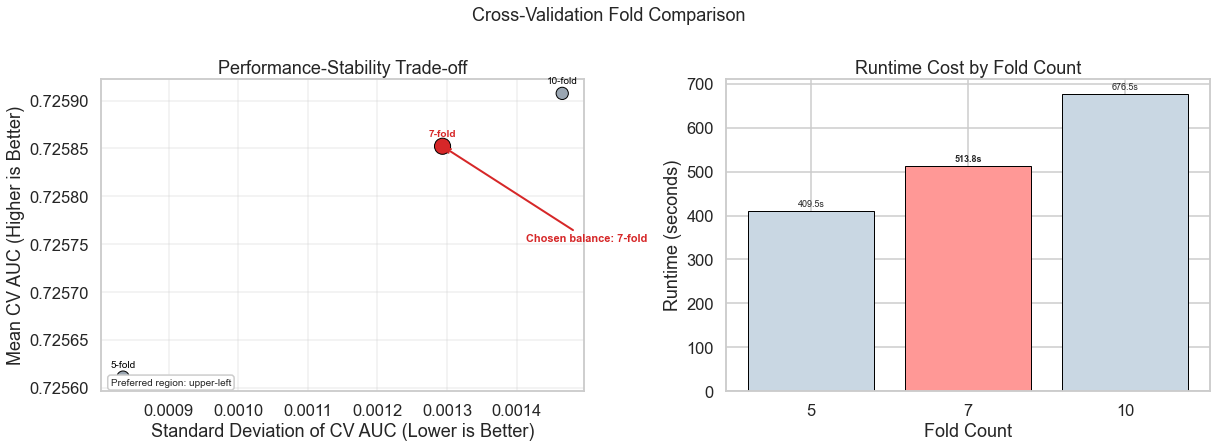

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

preferred_mask = results_df['fold_count'] == PREFERRED_FOLD
preferred_row = results_df.loc[preferred_mask].iloc[0]

scatter_colors = ['#9aa6b2' if fold != PREFERRED_FOLD else '#d62728' for fold in results_df['fold_count']]
scatter_sizes = [150 if fold != PREFERRED_FOLD else 260 for fold in results_df['fold_count']]

axes[0].scatter(
    results_df['std_auc'],
    results_df['mean_auc'],
    s=scatter_sizes,
    c=scatter_colors,
    edgecolors='black',
    linewidths=1.0,
)

for _, row in results_df.iterrows():
    axes[0].annotate(
        f"{int(row['fold_count'])}-fold",
        (row['std_auc'], row['mean_auc']),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center',
        fontsize=10,
        fontweight='bold' if row['fold_count'] == PREFERRED_FOLD else 'normal',
        color='#d62728' if row['fold_count'] == PREFERRED_FOLD else 'black',
    )

axes[0].annotate(
    f"Chosen balance: {PREFERRED_FOLD}-fold",
    xy=(preferred_row['std_auc'], preferred_row['mean_auc']),
    xytext=(preferred_row['std_auc'] + 0.00012, preferred_row['mean_auc'] - 0.00010),
    arrowprops=dict(arrowstyle='->', color='#d62728', lw=2),
    fontsize=11,
    color='#d62728',
    fontweight='bold',
)

axes[0].set_xlabel('Standard Deviation of CV AUC (Lower is Better)')
axes[0].set_ylabel('Mean CV AUC (Higher is Better)')
axes[0].set_title('Performance-Stability Trade-off')
axes[0].grid(True, alpha=0.3)

axes[0].text(
    0.02,
    0.02,
    'Preferred region: upper-left',
    transform=axes[0].transAxes,
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc'),
)

bar_colors = ['#c9d7e3' if fold != PREFERRED_FOLD else '#ff9896' for fold in results_df['fold_count']]
bars = axes[1].bar(results_df['fold_count'].astype(str), results_df['runtime_seconds'], color=bar_colors, edgecolor='black', linewidth=1.0)
axes[1].set_xlabel('Fold Count')
axes[1].set_ylabel('Runtime (seconds)')
axes[1].set_title('Runtime Cost by Fold Count')

for bar, (_, row) in zip(bars, results_df.iterrows()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        row['runtime_seconds'] + max(results_df['runtime_seconds']) * 0.015,
        f"{row['runtime_seconds']:.1f}s",
        ha='center',
        fontsize=9,
        fontweight='bold' if row['fold_count'] == PREFERRED_FOLD else 'normal',
    )

for tick_label in axes[1].get_xticklabels():
    if tick_label.get_text() == str(PREFERRED_FOLD):
        tick_label.set_color('#d62728')
        tick_label.set_fontweight('bold')

fig.suptitle('Cross-Validation Fold Comparison', fontsize=18, y=1.03)
fig.tight_layout()
fig.savefig(ARTIFACT_PNG, dpi=180, bbox_inches='tight')
plt.show()


## Recommendation Logic

The final choice is based on the trade-off across three dimensions:
- 5-fold is the lightest and most stable option in this run
- 10-fold gives the strongest mean AUC, but it is also the slowest and the least stable of the three
- 7-fold sits between them and provides the most practical balance between validation performance, stability, and runtime

When this notebook is run on the full training set, the 7-fold row should also align with the corresponding `src` training result, because the model, preprocessing, and CV logic are intentionally matched.


In [5]:
preferred_row = results_df.loc[results_df['fold_count'] == PREFERRED_FOLD].iloc[0]
best_mean_row = results_df.loc[results_df['mean_auc'].idxmax()]
lowest_std_row = results_df.loc[results_df['std_auc'].idxmin()]
fastest_row = results_df.loc[results_df['runtime_seconds'].idxmin()]

recommendation_lines = [
    f"**Recommended validation setting: {PREFERRED_FOLD}-fold cross-validation**",
    '',
    f"- Mean AUC for {PREFERRED_FOLD}-fold: **{preferred_row['mean_auc']:.6f}**",
    f"- Standard deviation for {PREFERRED_FOLD}-fold: **{preferred_row['std_auc']:.6f}**",
    f"- Highest mean AUC in this run: **{int(best_mean_row['fold_count'])}-fold** ({best_mean_row['mean_auc']:.6f})",
    f"- Lowest fold-to-fold standard deviation in this run: **{int(lowest_std_row['fold_count'])}-fold** ({lowest_std_row['std_auc']:.6f})",
    f"- Fastest runtime in this run: **{int(fastest_row['fold_count'])}-fold** ({fastest_row['runtime_seconds']:.2f} seconds)",
    '',
    f"A practical interpretation is that {PREFERRED_FOLD}-fold gives a stronger score than the most stable baseline while avoiding the full stability and runtime cost of the heaviest setting.",
    f"For this project, {PREFERRED_FOLD}-fold is therefore treated as the best balance between performance and stability, with runtime kept at a still-manageable level.",
]

display(Markdown('\n'.join(recommendation_lines)))


**Recommended validation setting: 7-fold cross-validation**

- Mean AUC for 7-fold: **0.725852**
- Standard deviation for 7-fold: **0.001294**
- Highest mean AUC in this run: **10-fold** (0.725908)
- Lowest fold-to-fold standard deviation in this run: **5-fold** (0.000835)
- Fastest runtime in this run: **5-fold** (409.46 seconds)

A practical interpretation is that 7-fold gives a stronger score than the most stable baseline while avoiding the full stability and runtime cost of the heaviest setting.
For this project, 7-fold is therefore treated as the best balance between performance and stability, with runtime kept at a still-manageable level.

## Save Artifacts

The notebook exports its comparison table, summary payload, markdown report, and main plot to `logs/`. These artifacts are generated by the notebook itself, so no earlier notebook execution is required.

In [6]:
summary_payload = {
    'max_train_rows': None if MAX_TRAIN_ROWS is None else int(MAX_TRAIN_ROWS),
    'preferred_fold': int(PREFERRED_FOLD),
    'selection_reason': '7-fold is selected as the best balance between validation performance, stability, and runtime.',
    'results': results_df.to_dict(orient='records'),
}

results_df.to_csv(ARTIFACT_CSV, index=False)
with open(ARTIFACT_JSON, 'w', encoding='utf-8') as handle:
    json.dump(summary_payload, handle, indent=2)

markdown_lines = [
    '# Fold Count Comparison',
    '',
    '## Comparison Results',
    dataframe_to_markdown(results_df[['fold_count', 'mean_auc', 'std_auc', 'oof_auc', 'runtime_seconds', 'preferred_fold']]),
    '',
    '## Recommendation',
    f'- Preferred validation setting: {PREFERRED_FOLD}-fold',
    f'- Primary reason: {PREFERRED_FOLD}-fold is selected as the best balance between validation performance, stability, and runtime.',
    '- 5-fold is more stable and faster, while 10-fold is slightly stronger on mean AUC but more expensive and less stable.',
]
ARTIFACT_MD.write_text(chr(10).join(markdown_lines), encoding='utf-8')

print(f'Saved comparison table: {ARTIFACT_CSV}')
print(f'Saved summary JSON: {ARTIFACT_JSON}')
print(f'Saved markdown summary: {ARTIFACT_MD}')
print(f'Saved plot: {ARTIFACT_PNG}')


Saved comparison table: c:\Users\LENOVO\Desktop\machinelearning_project\logs\fold_count_comparison.csv
Saved summary JSON: c:\Users\LENOVO\Desktop\machinelearning_project\logs\fold_count_comparison.json
Saved markdown summary: c:\Users\LENOVO\Desktop\machinelearning_project\logs\fold_count_comparison.md
Saved plot: c:\Users\LENOVO\Desktop\machinelearning_project\logs\fold_count_comparison.png


## Final Narrative Link

Notebook 12 studies tail-based validation behavior, while this notebook focuses on classical cross-validation design. Together they show that evaluation strategy became a central part of the project, not just a background implementation detail.

Within that story, Notebook 13 contributes the final CV-setting decision: 7-fold is retained not because it is the single best value on every metric, but because it offers the most practical balance between performance and stability for the later workflow. Notebook 13.5 then uses this choice as part of the overall experiment summary.
